In this notebook, we consider the results for the squared exponential correlation function.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import torch
import os
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process
from joblib import Parallel, delayed
import time


plt.rcParams.update({
    "text.usetex": True,  # Enable LaTeX rendering
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"], # Specify the font (classic LaTeX font)
    "text.latex.preamble": r"\usepackage{amsfonts}" 
})

In [2]:
crossing_type = "upcrossing"  
# crossing_type = "downcrossing"
# crossing_type = "crossing"
ModelClass = formula.GaussianUpCrossingsDimless

mean_rate_method = f"{crossing_type}_mean_rate"
fano_method = f"{crossing_type}_fano_factor_CLT"

In [3]:
if crossing_type == "downcrossing":
    fano_label = r'$\mathrm{F}^\downarrow$'
    mean_label = r'$\mathbb{E}\left[N^\downarrow_u(T)\right]/ \,T$'
    variance_label = r'Var$\left[N^\downarrow_u(T)\right]/ \,T$'
elif crossing_type == "upcrossing":
    fano_label = r'$\mathrm{F}^\uparrow$'
    mean_label = r'$\mathbb{E}\left[N^\uparrow_u(T)\right]/ \, T$'
    variance_label = r'Var$\left[N^\uparrow_u(T)\right]/ \, T$'
else:
    fano_label = r'$\mathrm{F}$'
    mean_label = r'$\mathbb{E}\left[N_u(T)\right]/ \, T$'
    variance_label = r'Var$\left[N_u(T)\right]/ \, T$'

In [4]:
# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
sigma = 1.0 # Standard deviation (amplitude) of the process

In [5]:
num_points_taus = 250
taus = torch.linspace(0.01, 1.0, num_points_taus)

num_points_psi = 250
psi = torch.linspace(0.0, 3.0, num_points_psi) 

mean_rates = torch.zeros(num_points_taus, num_points_psi)
fano_factors = torch.zeros(num_points_taus, num_points_psi)

In [6]:
def calculate_metrics(i, j, tau_val, psi_val, sigma_val, ModelClass, mean_rate_method, fano_method):
    """Calculates mean rate and Fano factor for given indices and parameters."""
    u = psi_val * sigma_val
    # Note: Ensure ModelClass and r_func are pickleable if using multiprocessing backend
    model = ModelClass(r_func=process.r_squared_exp, u=u, tau=tau_val, sigma=sigma_val)
    mean_rate = getattr(model, mean_rate_method)()
    fano_factor = getattr(model, fano_method)(epsilon_left=1e-5, epsilon_right=1e-5)
    return i, j, mean_rate, fano_factor

# Create list of delayed tasks
print("Preparing tasks for parallel execution...")
start_time = time.time()
tasks = [delayed(calculate_metrics)(i, j, taus[i], psi[j], sigma, ModelClass, mean_rate_method, fano_method)
         for i in range(num_points_taus) for j in range(num_points_psi)]

# Execute tasks in parallel
print(f"Starting parallel computation with {len(tasks)} tasks...")
# Use verbose=10 for progress updates
results = Parallel(n_jobs=-1, backend='loky', verbose=1)(tasks)
end_time = time.time()
print(f"Parallel computation finished in {end_time - start_time:.2f} seconds.")

# Process results and fill the tensors
print("Processing results...")
for i, j, mean_rate, fano_factor in results:
    mean_rates[i, j] = mean_rate
    fano_factors[i, j] = fano_factor
print("Results processed.")

# find the variance
variance = fano_factors * mean_rates

Preparing tasks for parallel execution...
Starting parallel computation with 62500 tasks...
Parallel computation finished in 22.09 seconds.
Processing results...
Results processed.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=-1)]: Done   185 out of 62500 | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 35081 out of 62500 | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done 62500 out of 62500 | elapsed:   21.8s finished


In [7]:
# for i in range(num_points_taus):
#     for j in range(num_points_psi):
#         u = psi[j] * sigma
#         tau = taus[i]
#         model = ModelClass(r_func=process.r_squared_exp, u=u, tau=tau, sigma=sigma)
#         mean_rates[i, j] = getattr(model, mean_rate_method)()
#         fano_factors[i, j] = getattr(model, fano_method)(epsilon_left=1e-5, epsilon_right=1e-5)

Info: Max Fano factor <= 1. Using sequential colormap (below).


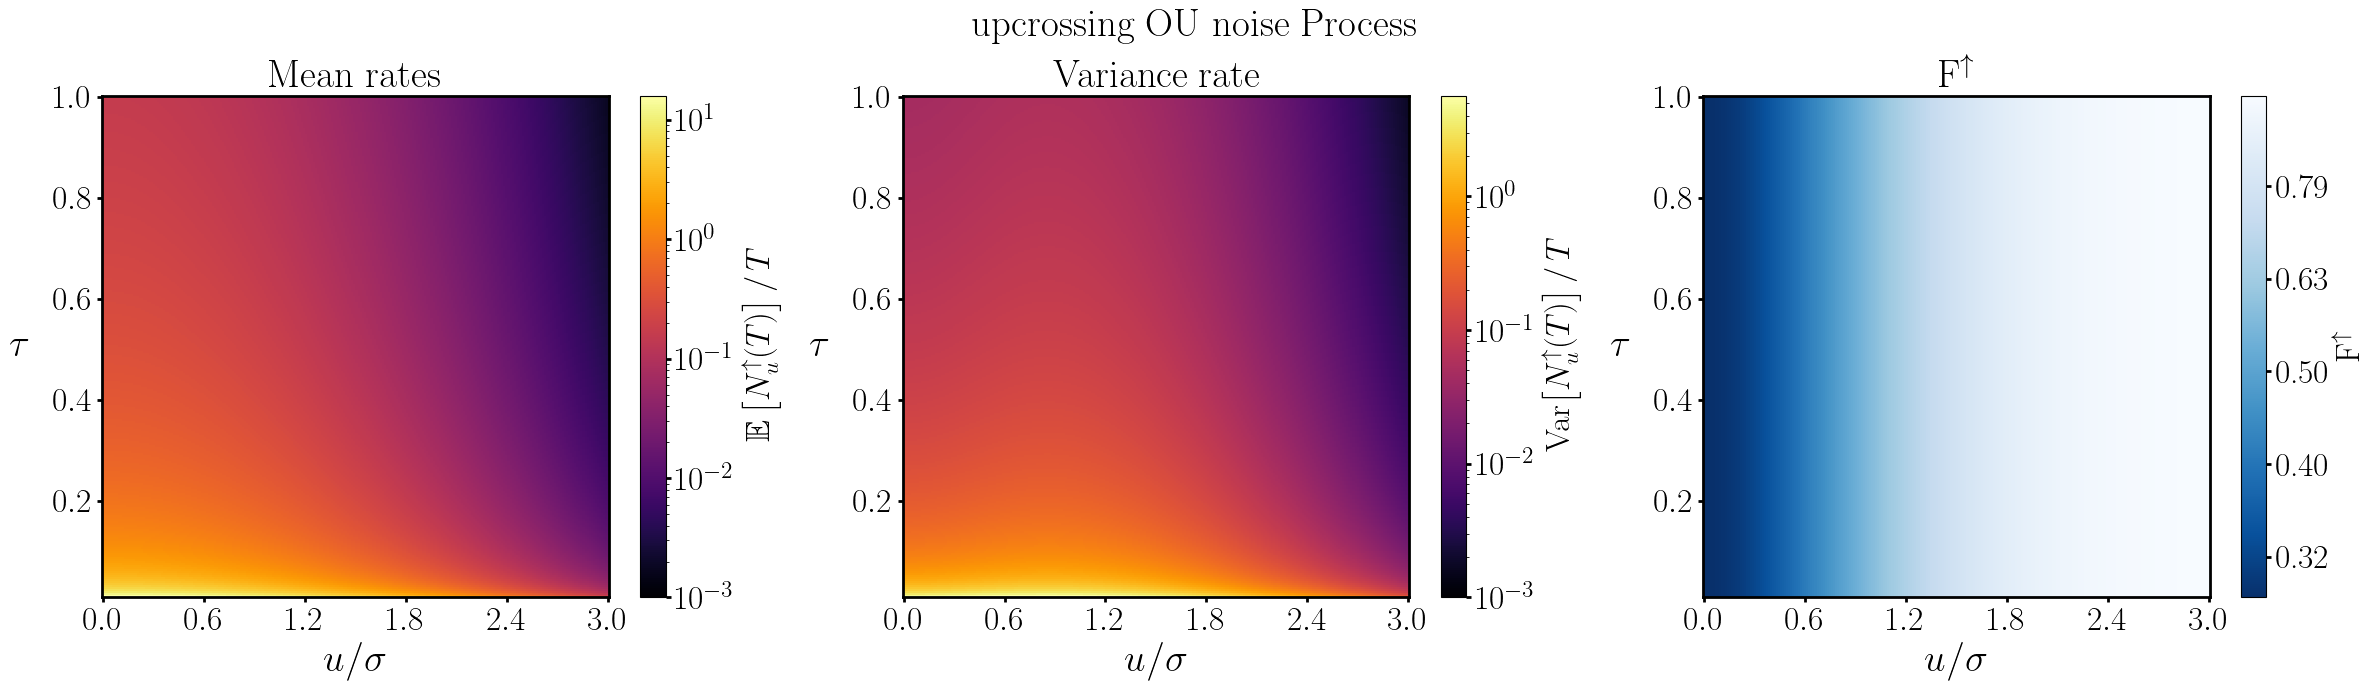

In [8]:
axis_label_fontsize = 28 # Fontsize for x and y labels & titles
tick_label_fontsize = 24 # Fontsize for tick labels & cbar labels/ticks
num_x_ticks = 6          # Desired number of ticks on the x-axis
num_y_ticks = 5          # Desired number of ticks on the y-axis
tick_line_width = 2.0    # Thickness of tick lines
spine_line_width = 2.0   # Thickness of plot border

# Keep original colormaps
cmap_mean = 'inferno'
cmap_variance = 'inferno'
cmap_diverging = 'PRGn'
cmap_below_1 = 'Blues_r'
cmap_above_1 = 'Reds'

# check which colormap to use for fano factors
fano_min = fano_factors.min().item()
fano_max = fano_factors.max().item()
spans_one = (fano_min < 1.0) and (fano_max > 1.0)

fano_log = torch.log10(fano_factors)
fano_log_np = fano_log.cpu().numpy() # Ensure data is NumPy array on CPU
log_min = fano_log_np.min() # Use numpy min/max now
log_max = fano_log_np.max()

# --- Select Colormap and Normalization ---
if spans_one:
    print("Info: Fano factor spans 1. Using diverging colormap.")
    cmap_fano = cmap_diverging
    # Use TwoSlopeNorm centered at log10(1) = 0
    norm_fano = mcolors.TwoSlopeNorm(vmin=log_min, vcenter=0, vmax=log_max)
else:
    # Data is all below or all above 1, use sequential map
    if fano_max <= 1.0:
        print("Info: Max Fano factor <= 1. Using sequential colormap (below).")
        cmap_fano = cmap_below_1
    else: # This implies fano_min >= 1.0
        print("Info: Min Fano factor >= 1. Using sequential colormap (above).")
        cmap_fano = cmap_above_1
    # Use simple linear normalization on the log-transformed data
    norm_fano = mcolors.Normalize(vmin=log_min, vmax=log_max)


# -----------------------
# Create the figure and subplots for Heatmaps
# Adjusted figsize slightly for larger fonts
fig, axes = plt.subplots(1, 3, figsize=(24, 7)) # Keep figsize from target, maybe slightly wider

# ---- Left subplot: Mean Rates ----
# Keep data calculation and normalization exactly as before
epsilon = 1e-3
adjusted_mean_rates = torch.clip(mean_rates, epsilon, None) # Use torch.clip
log_norm = mcolors.LogNorm(vmin=epsilon, vmax=adjusted_mean_rates.max())

pc0 = axes[0].pcolormesh(psi, taus, adjusted_mean_rates, shading='auto',
                         cmap=cmap_mean, norm=log_norm)
cbar0 = fig.colorbar(pc0, ax=axes[0])
# Apply new font sizes and tick width to colorbar
cbar0.set_label(mean_label, fontsize=tick_label_fontsize) # Use tick font size for cbar label
cbar0.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width) # Apply new size and width

# Apply new styling to axis 0
axes[0].set_xlabel(r'$u/\sigma$', fontsize=axis_label_fontsize)
axes[0].set_ylabel(r'$\tau$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=25) # New font size and rotation
axes[0].set_title('Mean rates', fontsize=axis_label_fontsize) # New font size

# Apply new tick locator, label size, and line width settings to axis 0
axes[0].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks)) # REPLACE manual ticks
axes[0].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks)) # REPLACE manual ticks
axes[0].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width) # Apply new size and width

# Apply new spine width settings to axis 0
for spine in axes[0].spines.values():
    spine.set_linewidth(spine_line_width)

# ------------- Middle subplot: Variance -------------
epsilon = 1e-3
adjusted_variance = torch.clip(variance, epsilon, None)
log_norm_var = mcolors.LogNorm(vmin=epsilon, vmax=adjusted_variance.max())

pc1 = axes[1].pcolormesh(psi, taus, adjusted_variance, shading='auto',
                         cmap=cmap_variance, norm=log_norm_var)
cbar1 = fig.colorbar(pc1, ax=axes[1])
cbar1.set_label(variance_label, fontsize=tick_label_fontsize)
cbar1.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width)

axes[1].set_xlabel(r'$u/\sigma$', fontsize=axis_label_fontsize)
axes[1].set_ylabel(r'$\tau$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=25)
axes[1].set_title('Variance rate', fontsize=axis_label_fontsize)

axes[1].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
axes[1].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))
axes[1].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

for spine in axes[1].spines.values():
    spine.set_linewidth(spine_line_width)
    

# plot the Fano factor
pc2 = axes[2].pcolormesh(psi, taus, fano_log, shading='auto',
                         cmap=cmap_fano, norm=norm_fano)
cbar2 = fig.colorbar(pc2, ax=axes[2])
# Apply new font sizes and tick width to colorbar
cbar2.set_label(fano_label, fontsize=tick_label_fontsize) # Use tick font size for cbar label
cbar2.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width) # Apply new size and width

# Keep original colorbar formatter
def log_tick_formatter(x, pos):
    return f"{10**x:.2f}" # Keep original formatter function
cbar2.formatter = mticker.FuncFormatter(log_tick_formatter)
cbar2.update_ticks()

# Apply new styling to axis 1
axes[2].set_xlabel(r'$u/\sigma$', fontsize=axis_label_fontsize)
axes[2].set_ylabel(r'$\tau$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=25) # New font size and rotation
axes[2].set_title(fano_label, fontsize=axis_label_fontsize) # New font size

# Apply new tick locator, label size, and line width settings to axis 1
axes[2].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks)) # REPLACE manual ticks
axes[2].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks)) # REPLACE manual ticks
axes[2].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width) # Apply new size and width

# Apply new spine width settings to axis 1
for spine in axes[2].spines.values():
    spine.set_linewidth(spine_line_width)

# Apply new font size to suptitle
fig.suptitle(f"{crossing_type} OU noise Process", fontsize=axis_label_fontsize) # Use axis label size

plt.tight_layout() 

# Save the figure
folder_loc = f'../../figures/squared_exp/'
os.makedirs(folder_loc, exist_ok=True)
file_name = f'phase_diagram_{crossing_type}' 
file_save_path = os.path.join(folder_loc, file_name)
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()

In [9]:
model = ModelClass(r_func=process.r_squared_exp, u=0.0, tau=1.0, sigma=sigma)
print(getattr(model, fano_method)(epsilon_left=1e-2, epsilon_right=1e-5))

tensor(0.2859)


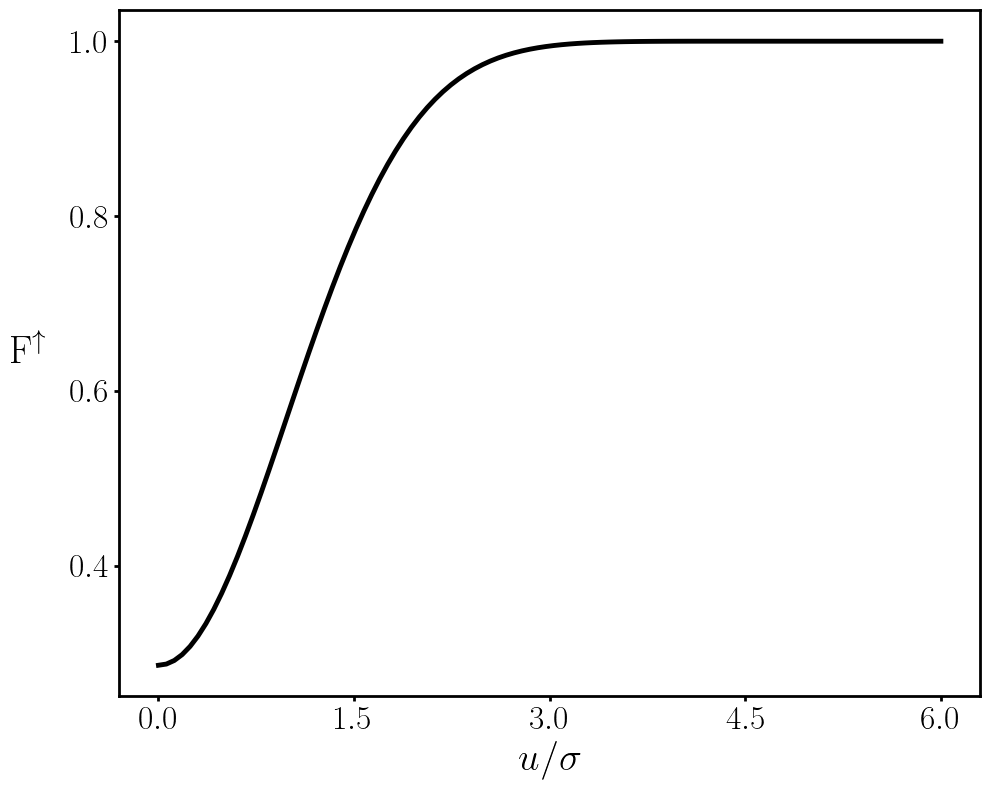

In [10]:
axis_label_fontsize = 28 # Fontsize for x and y labels & titles
tick_label_fontsize = 24 # Fontsize for tick labels & cbar labels/ticks
num_x_ticks = 6          # Desired number of ticks on the x-axis
num_y_ticks = 5          # Desired number of ticks on the y-axis
tick_line_width = 2.0    # Thickness of tick lines
spine_line_width = 2.0   # Thickness of plot border

psi = torch.linspace(0.0, 6.0, 100)
fano_factors = torch.zeros_like(psi)
for i in range(len(psi)):
    model = ModelClass(r_func=process.r_squared_exp, u=psi[i] * sigma, tau=1.0, sigma=sigma)
    fano_factors[i] = getattr(model, fano_method)(epsilon_left=1e-2, epsilon_right=1e-5)

# --- Plotting the Fano factor curve with new style ---
plt.figure(figsize=(10, 8)) # Apply figsize from source script
ax = plt.gca() # Get axes instance

# Plot using ax, apply new linewidth and color
ax.plot(psi, fano_factors, linewidth=3.5, color='k') # Apply new linewidth

# Apply new styling (labels, ticks, spines)
ax.set_xlabel(r'$u/\sigma$', fontsize=axis_label_fontsize) # Apply new font size
ax.set_ylabel(fano_label, fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=30) # Apply new font size and rotation

# Apply new tick locator, label size, and line width settings
ax.xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks)) # REPLACE original MaxNLocator call
ax.yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks)) # REPLACE original MaxNLocator call
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width) # Apply new size and width

# Apply new spine width settings
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)

#save the figure
plt.tight_layout() 
folder_loc = f'../../figures/squared_exp/'
os.makedirs(folder_loc, exist_ok=True)
file_name = f'fano_factor_{crossing_type}_psi' 
file_save_path = os.path.join(folder_loc, file_name)
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show() 